# Customer Churn Prediction — Exploratory Data Analysis

## Objective

The objective of this analysis is to explore customer behavior and identify
patterns and factors that are associated with customer churn.

We will analyze numerical and categorical features and investigate their
relationship with the target variable, `Churn`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv(
    "../data/cleaned/telco_customer_churn_cleaned.csv"
)

data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Dataset Overview

In [10]:
data.shape

(7043, 21)

In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 2. Churn Distribution

Before analyzing individual features, we examine the distribution of the
target variable.

This helps us understand the proportion of customers who churned compared
with customers who remained with the company.

In [12]:
data["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
churn_percentage = (
    data["Churn"]
    .value_counts(normalize=True)
    * 100
)

churn_percentage

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

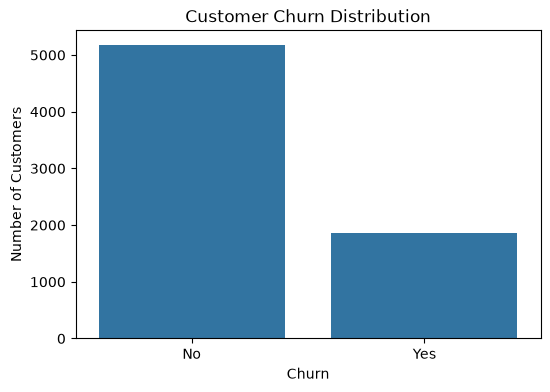

In [14]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=data,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The majority of customers have not churned, while a smaller proportion have
churned.

The target variable is therefore imbalanced, with churned customers
representing approximately 26.5% of the dataset.

This imbalance should be considered when evaluating classification models.

## 3. Numerical Feature Distributions

We examine the distributions of numerical variables to understand their
range, concentration, and overall patterns.

In [16]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

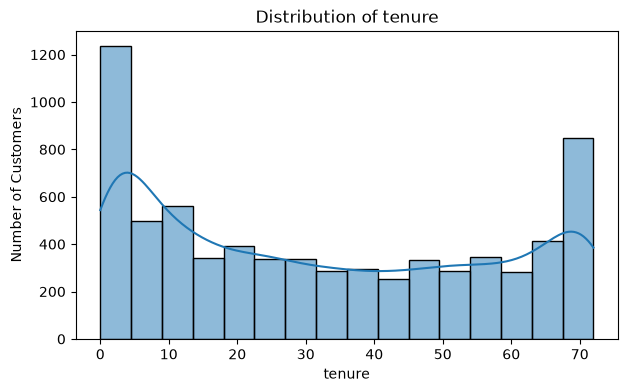

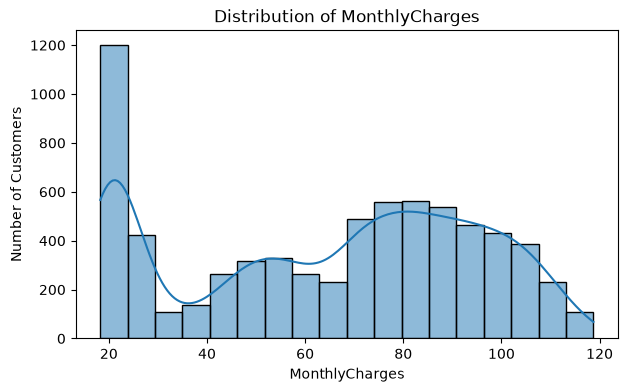

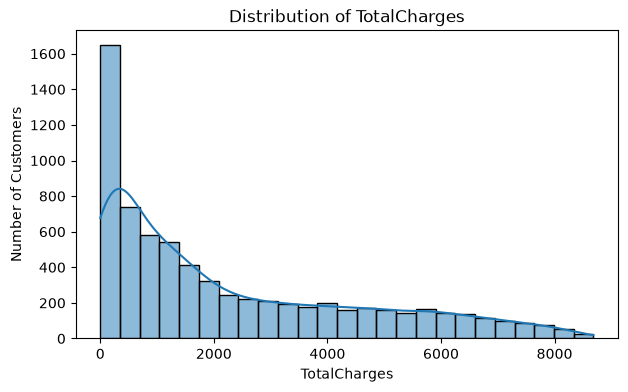

In [17]:
for column in numeric_features:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=data,
        x=column,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Customers")

    plt.show()

## 4. Does Customer Tenure Relate to Churn?

`tenure` represents the number of months a customer has been with the company.

We investigate whether customers with different tenure levels show different
churn behavior.

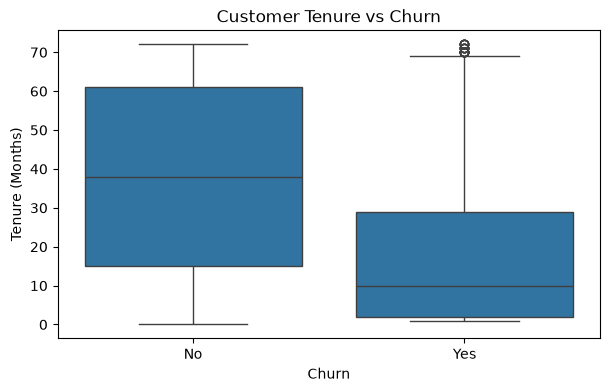

In [18]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=data,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [19]:
data.groupby("Churn")["tenure"].median()

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64

In [20]:
data.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

### Observation

Customers who churn appear to have lower tenure compared with customers
who remain with the company.

This suggests that customer tenure may be an important predictor of churn.

## 5. Does Monthly Spending Relate to Churn?

We investigate whether customers with different monthly charges show
different churn behavior.

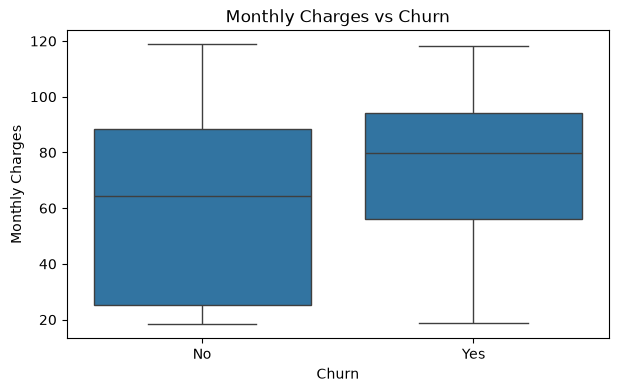

In [22]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=data,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [23]:
data.groupby("Churn")["MonthlyCharges"].median()

Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64

## 6. Does Total Spending Relate to Churn?

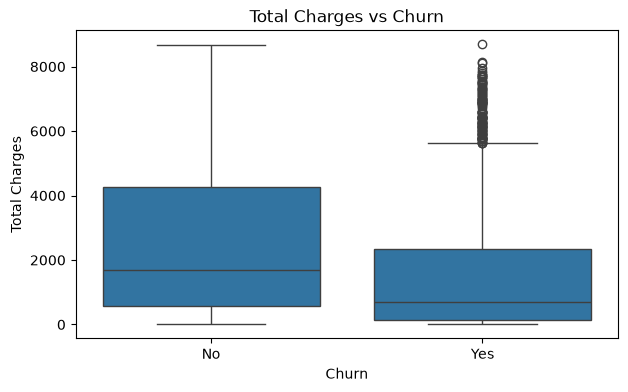

In [24]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=data,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

## 7. Does Contract Type Affect Churn?

Customers can have different contract types.

We investigate whether churn rates differ across contract types.

In [25]:
pd.crosstab(
    data["Contract"],
    data["Churn"]
)

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [26]:
contract_churn = (
    pd.crosstab(
        data["Contract"],
        data["Churn"],
        normalize="index"
    ) * 100
)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


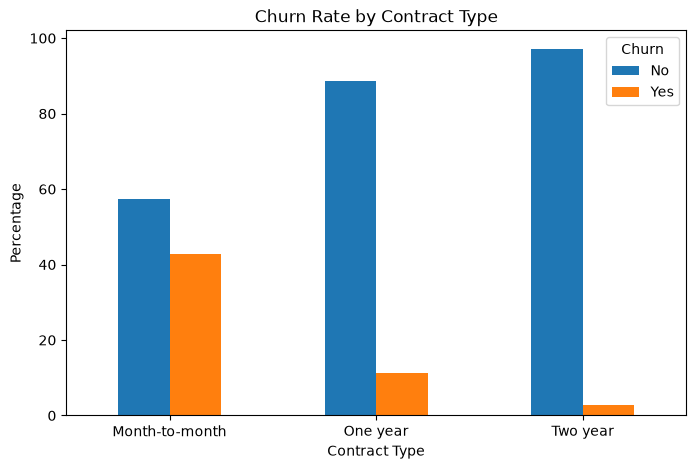

In [27]:
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

## 8. Does Internet Service Type Relate to Churn?

In [28]:
internet_churn = (
    pd.crosstab(
        data["InternetService"],
        data["Churn"],
        normalize="index"
    ) * 100
)

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


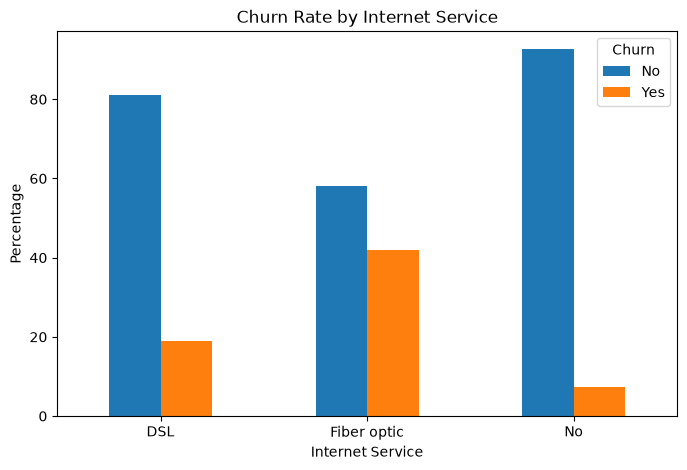

In [29]:
internet_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

## 9. Does Technical Support Relate to Churn?

In [30]:
tech_support_churn = (
    pd.crosstab(
        data["TechSupport"],
        data["Churn"],
        normalize="index"
    ) * 100
)

tech_support_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


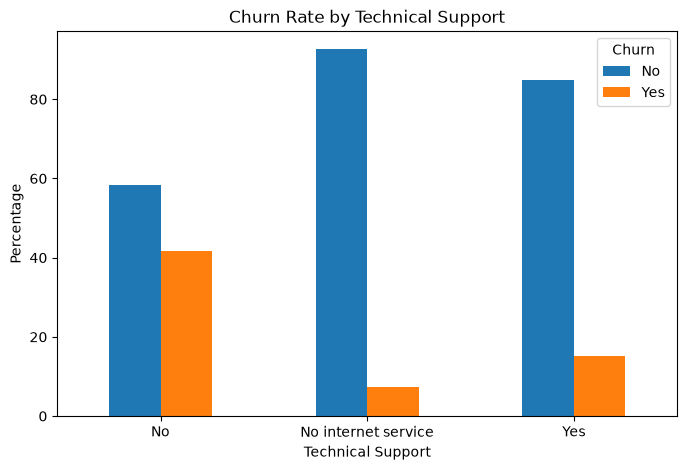

In [31]:
tech_support_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Technical Support")
plt.xlabel("Technical Support")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

## 10. Does Payment Method Relate to Churn?

In [32]:
payment_churn = (
    pd.crosstab(
        data["PaymentMethod"],
        data["Churn"],
        normalize="index"
    ) * 100
)

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


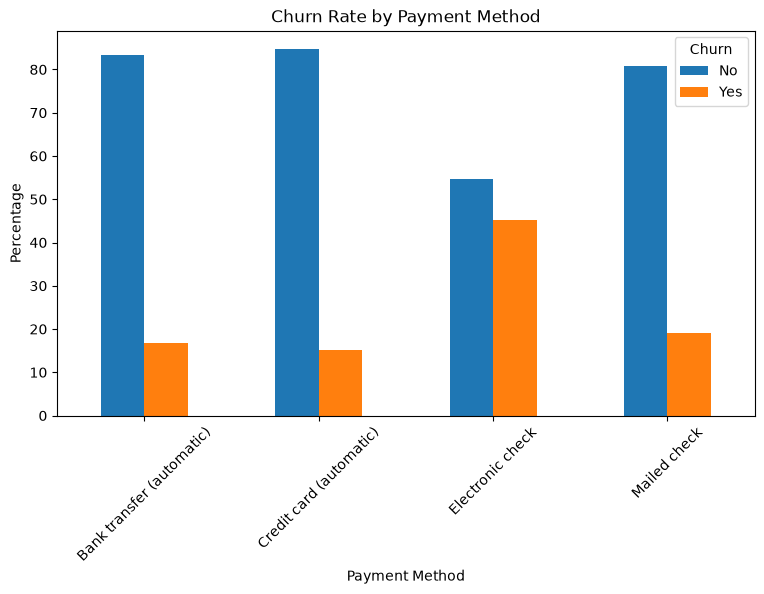

In [33]:
payment_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage")
plt.xticks(rotation=45)

plt.show()

## 11. Correlation Analysis

Correlation measures the strength and direction of a linear relationship
between numerical variables.

We examine the correlations between numerical features.

In [34]:
correlation = data[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].corr()

correlation

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


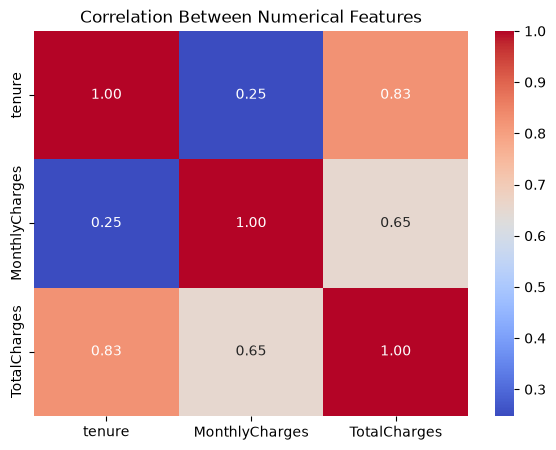

In [35]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")

plt.show()

# EDA Summary

The exploratory analysis was performed to identify patterns associated with
customer churn.

Key areas investigated:

- Overall churn distribution
- Customer tenure
- Monthly charges
- Total charges
- Contract type
- Internet service
- Technical support
- Payment method
- Correlation between numerical features

The analysis suggests that some customer characteristics have noticeably
different churn rates across their categories.

These findings will be used to guide feature engineering and model
development.

EDA does not establish causation. The identified relationships will be
further evaluated using statistical analysis and machine learning models.